<a href="https://colab.research.google.com/github/Janmeshree/ML-PRACS/blob/main/ML_LOGISTIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [7]:
df = df.dropna()

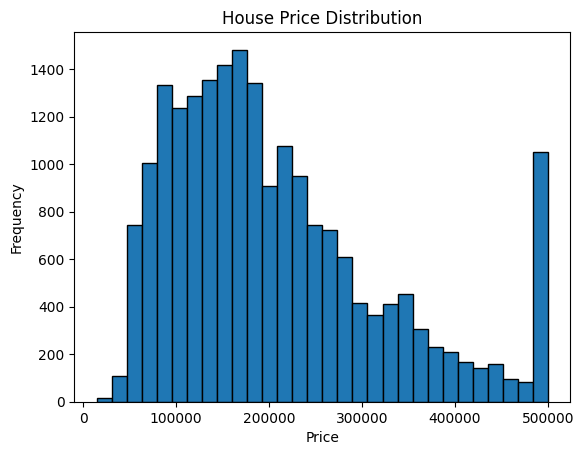

In [8]:
plt.hist(df["median_house_value"], bins=30, edgecolor="black")
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [9]:
df = df.sample(100, random_state=42)

In [10]:
median_price = df["median_house_value"].median()

df["price_class"] = (df["median_house_value"] > median_price).astype(int)

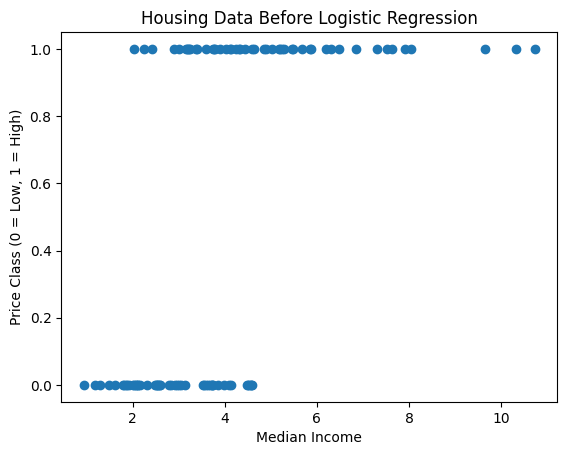

In [11]:
plt.scatter(df["median_income"], df["price_class"])

plt.xlabel("Median Income")
plt.ylabel("Price Class (0 = Low, 1 = High)")
plt.title("Housing Data Before Logistic Regression")

plt.show()

In [12]:
X = df[["median_income"]]
y = df["price_class"]

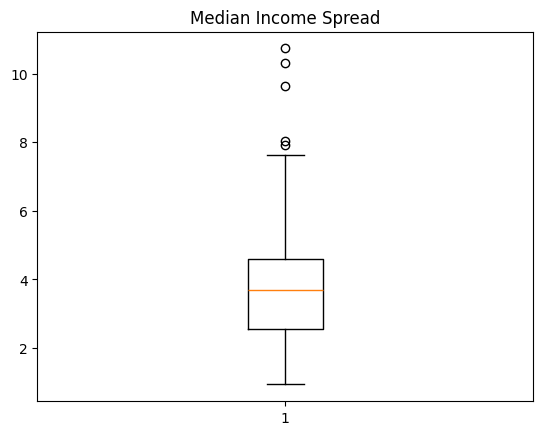

In [13]:
plt.boxplot(df["median_income"])
plt.title("Median Income Spread")
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [16]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [17]:
train_acc = accuracy_score(y_train, y_pred_train)

print("Training Accuracy:", train_acc)

Training Accuracy: 0.775


In [18]:
test_acc = accuracy_score(y_test, y_pred_test)

print("Testing Accuracy:", test_acc)

Testing Accuracy: 0.75


In [19]:
if train_acc > test_acc + 0.1:
    print("Model is Overfitting")
elif test_acc > train_acc:
    print("Model may be Underfitting")
else:
    print("Model is Well Fitted")

Model is Well Fitted


In [20]:
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[7 2]
 [3 8]]


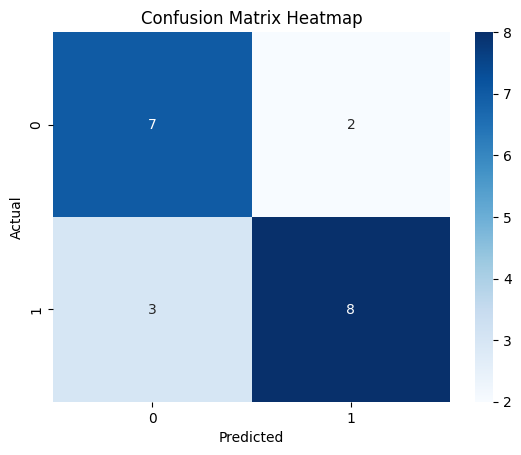

In [21]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.75
Precision: 0.8
Recall: 0.7272727272727273
F1 Score: 0.7619047619047619


In [23]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.70      0.78      0.74         9
           1       0.80      0.73      0.76        11

    accuracy                           0.75        20
   macro avg       0.75      0.75      0.75        20
weighted avg       0.76      0.75      0.75        20



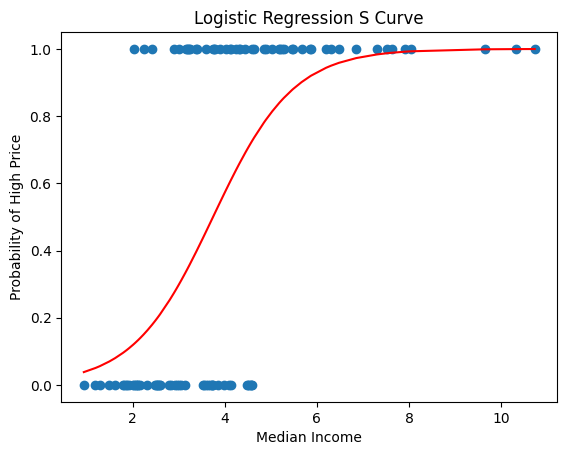

In [24]:
# predicted probabilities
y_prob = model.predict_proba(X)[:,1]

# sort values for smooth curve
sorted_index = X["median_income"].argsort()

X_sorted = X["median_income"].iloc[sorted_index]
y_prob_sorted = y_prob[sorted_index]

# plot data points
plt.scatter(X["median_income"], y)

# plot S curve
plt.plot(X_sorted, y_prob_sorted, color="red")

plt.xlabel("Median Income")
plt.ylabel("Probability of High Price")
plt.title("Logistic Regression S Curve")

plt.show()